In [9]:
# === Imports ===
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# === Load Data ===
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['indicator', 'date']).reset_index(drop=True)

# === Select One Indicator ===
# Manually specify the indicator you want to model
indicator_id = "146.71.50.198" 
data = df[df['indicator'] == indicator_id].sort_values('date').reset_index(drop=True)
print(f"Using indicator: {indicator_id}, total records: {len(data)}")

# === Create Sequences ===
sequence_length = 30
X, y = [], []

for i in range(len(data) - sequence_length):
    X.append(data['seen'].iloc[i:i+sequence_length].values)
    y.append(data['seen'].iloc[i+sequence_length])

X = np.array(X).astype(np.float32)
y = np.array(y).astype(np.float32)
X = X.reshape((X.shape[0], X.shape[1], 1))  # [samples, time steps, features]

# === Train/Test Split ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# === Build LSTM Model ===
model = Sequential([
    LSTM(64, input_shape=(X.shape[1], 1)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# === Train ===
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=8,
    callbacks=[early_stop],
    verbose=1
)

# === Evaluate ===
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int)

print(classification_report(y_test, y_pred))
print(f"AUC Score: {roc_auc_score(y_test, y_pred_prob):.4f}")

for i in range(len(y_test)):
    actual = int(y_test[i])
    predicted = int(y_pred[i])
    confidence = float(y_pred_prob[i])
    print(f"Sample {i+1}: Actual = {'Seen' if actual == 1 else 'Not Seen'}, Predicted = {'Seen' if predicted == 1 else 'Not Seen'}, Confidence = {confidence:.3f}")



Using indicator: 146.71.50.198, total records: 120
Epoch 1/20


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.5616 - loss: 0.6905 - val_accuracy: 0.6667 - val_loss: 0.6671
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6656 - loss: 0.6615 - val_accuracy: 0.6667 - val_loss: 0.6479
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5962 - loss: 0.6799 - val_accuracy: 0.6667 - val_loss: 0.6387
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6154 - loss: 0.6619 - val_accuracy: 0.6667 - val_loss: 0.6295
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5552 - loss: 0.6899 - val_accuracy: 0.6667 - val_loss: 0.6196
Epoch 6/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.6027 - loss: 0.6647 - val_accuracy: 0.6667 - val_loss: 0.6186
Epoch 7/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.6040 - loss: 0.6848 - val_accuracy: 0.6667 - val_loss: 0.6170
Epoch 8/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5756 - loss: 0.6692 - val_accuracy: 0.6667 - val_loss: 0.6062
Epoch 9/20


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

In [21]:
# === Setup ===
import pandas as pd
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.model_selection import train_test_split

# Parameters
sequence_length = 30
forecast_day = pd.to_datetime("2025-04-30")
cutoff_date = forecast_day - pd.Timedelta(days=7)

# Load data
df = pd.read_csv(r"C:\Users\jaskew\Documents\project_repository\notebooks\observationEventForecasting\DataPreprocessing\FullIndicatorMatrix.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['indicator', 'date']).reset_index(drop=True)

# Get all indicators (or use .index[:N] for top N)
indicators_to_run = df['indicator'].value_counts().index

# === Store forecast results ===
results = []

# === Run LSTM forecast per indicator ===
for indicator_id in indicators_to_run:
    data = df[df['indicator'] == indicator_id].sort_values('date').reset_index(drop=True)
    past_data = data[data['date'] < cutoff_date]

    if len(past_data) < sequence_length + 1:
        continue

    # Build training sequences
    X, y = [], []
    for i in range(len(past_data) - sequence_length):
        X.append(past_data['seen'].iloc[i:i+sequence_length].values)
        y.append(past_data['seen'].iloc[i + sequence_length])

    X = np.array(X).astype(np.float32).reshape((-1, sequence_length, 1))
    y = np.array(y).astype(np.float32)

    # Train LSTM
    X_train, _, y_train, _ = train_test_split(X, y, test_size=0.1, random_state=42)
    model = Sequential([
        LSTM(32, input_shape=(sequence_length, 1)),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy')
    model.fit(X_train, y_train, epochs=10, batch_size=8, verbose=0)

    # Predict using most recent 30 days
    latest_seq = past_data['seen'].iloc[-sequence_length:].values.reshape(1, sequence_length, 1).astype(np.float32)
    prediction_prob = model.predict(latest_seq)[0][0]
    prediction = int(prediction_prob > 0.5)

    # Store in DataFrame
    results.append({
        "Indicator": indicator_id,
        "Forecast Date": forecast_day.date(),
        "Predicted Seen": "Yes" if prediction else "No",
        "Confidence": round(prediction_prob, 3)
    })

# === Final result ===
results_df = pd.DataFrame(results)
results_df


C:\Users\jaskew\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 278ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 829ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 254ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

,Indicator,Forecast Date,Predicted Seen,Confidence
0,102.129.153.158,2025-04-30,No,0.020
1,102.129.153.43,2025-04-30,No,0.023
2,102.129.153.71,2025-04-30,No,0.046
3,102.165.16.161,2025-04-30,No,0.067
4,104.160.6.2,2025-04-30,No,0.021
...,...,...,...,...
203,international.standardbank.com/,2025-04-30,No,0.002
204,pub.marq.com/,2025-04-30,No,0.063
205,realinvestmentadvice.com/,2025-04-30,No,0.073
206,www.emergencylighting.com/,2025-04-30,No,0.021


In [24]:
results_df.columns

Index(['Indicator', 'Forecast Date', 'Predicted Seen', 'Confidence'], dtype='object')

In [30]:
predicted_seen = results_df[results_df['Predicted Seen'] == 'Yes']
predicted_seen.columns = predicted_seen.columns.str.lower()
predicted_seen

,indicator,forecast date,predicted seen,confidence
8,104.21.48.1,2025-04-30,Yes,0.979
9,104.21.54.132,2025-04-30,Yes,0.826
10,104.21.61.32,2025-04-30,Yes,0.539
50,162.142.125.242,2025-04-30,Yes,0.861
51,162.142.125.247,2025-04-30,Yes,0.847
52,162.142.125.255,2025-04-30,Yes,0.799
58,172.240.108.68,2025-04-30,Yes,0.798
65,185.230.63.171,2025-04-30,Yes,0.771
123,34.160.111.145,2025-04-30,Yes,0.811
185,68.67.179.164,2025-04-30,Yes,0.986


In [28]:
current_seen_data = df[(df['date'] == '2025-04-30') & (df['seen'] == 1)]
current_seen_data

,API_UserName,date,indicator,observations,dayofweek,is_weekend,day,month,seen
1079,818860012482918321,2025-04-30,104.21.48.1,240,2,False,30,4,1
1199,818860012482918321,2025-04-30,104.21.54.132,2,2,False,30,4,1
6239,818860012482918321,2025-04-30,162.142.125.247,2,2,False,30,4,1
6359,818860012482918321,2025-04-30,162.142.125.255,1,2,False,30,4,1
7079,818860012482918321,2025-04-30,172.240.108.68,7,2,False,30,4,1
7919,818860012482918321,2025-04-30,185.230.63.171,17,2,False,30,4,1
22079,818860012482918321,2025-04-30,66.22.212.131,1,2,False,30,4,1
22319,818860012482918321,2025-04-30,68.67.179.164,809,2,False,30,4,1


In [36]:
missed_indicators = predicted_seen.merge(
    current_seen_data,
    how='outer',
    on='indicator',
    indicator=True
)
missed_indicators = missed_indicators[missed_indicators['_merge'] != 'both']
missed_indicators

,indicator,forecast date,predicted seen,confidence,API_UserName,date,observations,dayofweek,is_weekend,day,month,seen,_merge
2,104.21.61.32,2025-04-30,Yes,0.539,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
3,162.142.125.242,2025-04-30,Yes,0.861,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
8,34.160.111.145,2025-04-30,Yes,0.811,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,left_only
9,66.22.212.131,NaN,NaN,NaN,8.188600e+17,2025-04-30,1.0,2.0,False,30.0,4.0,1.0,right_only


In [38]:
missed_indicators_activity = df[df['indicator'].isin(missed_indicators['indicator'])]


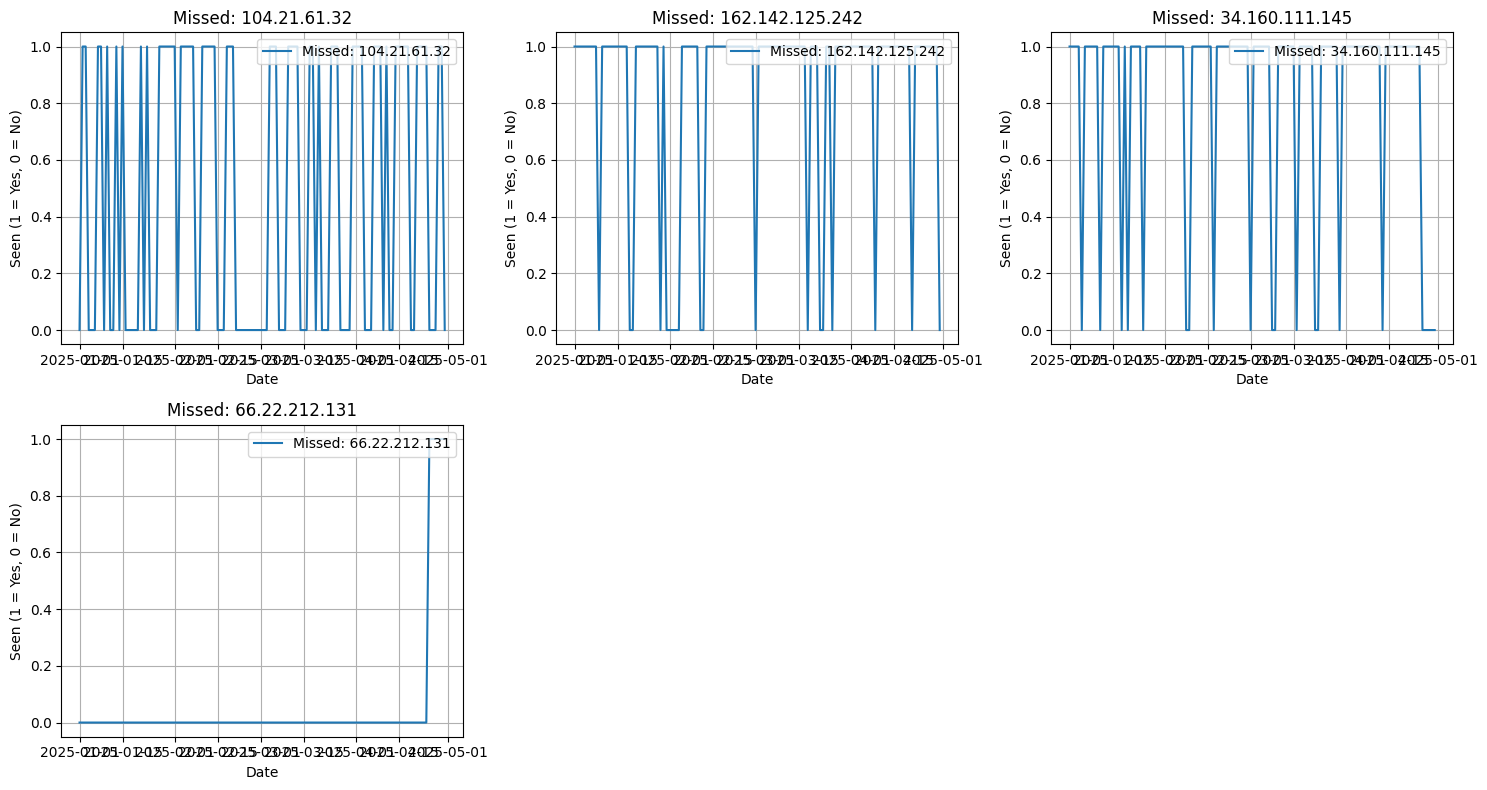

In [39]:
import matplotlib.pyplot as plt
import math

# Function to plot indicators in a grid
def plot_indicators_in_grid(activity_data, indicators, title_prefix):
    num_indicators = len(indicators)
    cols = 3  # Number of columns in the grid
    rows = math.ceil(num_indicators / cols)  # Calculate rows needed

    fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
    axes = axes.flatten()  # Flatten the axes array for easy iteration

    for i, indicator in enumerate(indicators):
        ax = axes[i]
        indicator_data = activity_data[activity_data['indicator'] == indicator]
        ax.plot(indicator_data['date'], indicator_data['seen'], label=f'{title_prefix}: {indicator}')
        ax.set_title(f'{title_prefix}: {indicator}')
        ax.set_xlabel('Date')
        ax.set_ylabel('Seen (1 = Yes, 0 = No)')
        ax.legend(loc='upper right')
        ax.grid(True)

    # Hide any unused subplots
    for i in range(len(indicators), len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Plot false positives in a grid
plot_indicators_in_grid(missed_indicators_activity, missed_indicators['indicator'].unique(), 'Missed')

